## EV heatmap over (b1, b2) for several assumed avg_b2 values

For each assumed field `avg_b2` we sweep integer bids `b1 ∈ [700, 800]` and
`b2 ∈ [800, 900]`, compute the strict-convention analytic EV per counterparty,
and plot a heatmap. The per-panel argmax tells you the best response under that
belief about the field. The key question: how far up do you chase `avg_b2`?

Reference (no-penalty) optimum: b1=751, b2=836, EV=84.3333

  avg_b2     b1*     b2*       EV*
----------------------------------
     830     751     836   84.3333
     840     751     841   84.2157
     846     756     846   84.0000
     855     761     856   83.0784
     865     766     866   81.5686


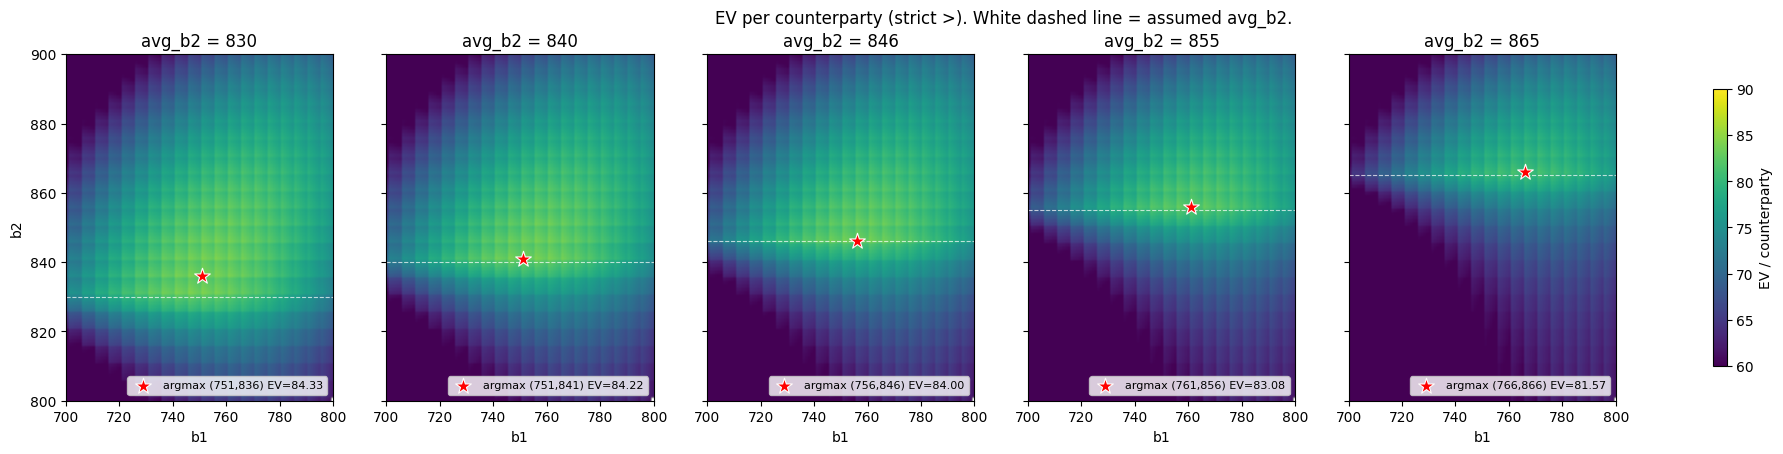

In [6]:
import numpy as np
import matplotlib.pyplot as plt

SELL = 920
RESERVE_GRID = np.arange(670, 921, 5)
N_GRID = len(RESERVE_GRID)

B1_RANGE = np.arange(700, 801)   # 101 values
B2_RANGE = np.arange(800, 901)   # 101 values

# Vectorised EV: precompute n1(b1) and n2(b1, b2) over the integer grids.
#   n1[i] = # grid reserves strictly less than B1_RANGE[i]
#   cum[j] = # grid reserves strictly less than B2_RANGE[j]
#   n2[i, j] = cum[j] - n1[i]    (valid when b2 > b1; we mask b2 <= b1 later)
n1 = np.array([(RESERVE_GRID < b).sum() for b in B1_RANGE])       # shape (I,)
cum = np.array([(RESERVE_GRID < b).sum() for b in B2_RANGE])       # shape (J,)
n2 = cum[None, :] - n1[:, None]                                    # (I, J)

margin1 = (SELL - B1_RANGE)[:, None]                               # (I, 1)
margin2 = (SELL - B2_RANGE)[None, :]                               # (1, J)

# Mask infeasible regions (b2 <= b1) — set EV to NaN so they render blank.
B1_grid, B2_grid = np.meshgrid(B1_RANGE, B2_RANGE, indexing="ij")
infeasible = B2_grid <= B1_grid


def ev_grid(avg_b2):
    """Return (I, J) array of EV per counterparty for each (b1, b2) combo."""
    # Penalty multiplier depends elementwise on whether b2 > avg_b2
    pen = np.where(
        B2_RANGE[None, :] > avg_b2,
        1.0,
        ((SELL - avg_b2) / np.where(SELL - B2_RANGE[None, :] > 0,
                                    SELL - B2_RANGE[None, :], 1)) ** 3,
    )
    ev = (n1[:, None] * margin1 + n2 * margin2 * pen) / N_GRID
    ev = np.where(infeasible, np.nan, ev)
    return ev


assumed_avgs = [830, 840, 846, 855, 865]

# Reference: global no-penalty argmax (should be (751, 836))
ref_ev = ev_grid(avg_b2=-np.inf)  # any avg below all b2 -> no penalty regime
ref_i, ref_j = np.unravel_index(np.nanargmax(ref_ev), ref_ev.shape)
print(f"Reference (no-penalty) optimum: b1={B1_RANGE[ref_i]}, "
      f"b2={B2_RANGE[ref_j]}, EV={ref_ev[ref_i, ref_j]:.4f}")
print()

fig, axes = plt.subplots(1, len(assumed_avgs), figsize=(5 * len(assumed_avgs), 4.5),
                         sharey=True)
print(f"{'avg_b2':>8}{'b1*':>8}{'b2*':>8}{'EV*':>10}")
print("-" * 34)
for ax, a in zip(axes, assumed_avgs):
    ev = ev_grid(a)
    i_star, j_star = np.unravel_index(np.nanargmax(ev), ev.shape)
    b1_star, b2_star, ev_star = B1_RANGE[i_star], B2_RANGE[j_star], ev[i_star, j_star]
    print(f"{a:>8}{b1_star:>8}{b2_star:>8}{ev_star:>10.4f}")

    im = ax.imshow(
        ev.T,
        origin="lower",
        aspect="auto",
        extent=[B1_RANGE[0], B1_RANGE[-1], B2_RANGE[0], B2_RANGE[-1]],
        cmap="viridis",
        vmin=60, vmax=90,
    )
    ax.scatter([b1_star], [b2_star], marker="*", s=140, color="red",
               edgecolor="white", linewidth=0.8, zorder=5,
               label=f"argmax ({b1_star},{b2_star}) EV={ev_star:.2f}")
    ax.axhline(a, color="white", linestyle="--", linewidth=0.8, alpha=0.7)
    ax.set_title(f"avg_b2 = {a}")
    ax.set_xlabel("b1")
    ax.legend(loc="lower right", fontsize=8)
axes[0].set_ylabel("b2")
fig.suptitle("EV per counterparty (strict >). White dashed line = assumed avg_b2.")
fig.colorbar(im, ax=axes, label="EV / counterparty", shrink=0.8)
plt.show()

[np.float64(-8.822278911564625), np.float64(-8.787025085034013), np.float64(-8.751841836734695), np.float64(-8.716729166666667), np.float64(-8.681687074829933), np.float64(-8.64671556122449), np.float64(-8.61181462585034), np.float64(-8.576984268707482), np.float64(-8.542224489795919), np.float64(-8.507535289115646)]
[np.float64(-0.0035289115646258504), np.float64(-0.0028584183673469386), np.float64(-0.002258503401360544), np.float64(-0.0017291666666666666), np.float64(-0.0012704081632653062), np.float64(-0.0008822278911564626), np.float64(-0.000564625850340136), np.float64(-0.00031760204081632655), np.float64(-0.000141156462585034), np.float64(-3.52891156462585e-05)]


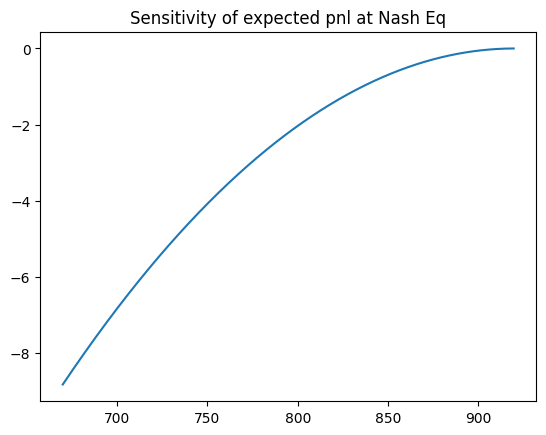

In [22]:
# marginal change of EV(penalty-pnl)
# g = EV(penalty-pnl)

b_bars = np.arange(670, 920, 0.5)
b1s = np.arange(670, 920, 1)
b2s = np.arange(670, 920, 1)

def partial_g_b_bar(b1,b2,b_bar):
    num = -3 * (b2 - b1) * (920 - b_bar)**2
    denom = 250 * (920 - b2)**2
    return num / denom

# sensity of g given Nash eq. at b1* = 753, b2* = 836
partials = []
for b_bar in b_bars:
    partials.append(partial_g_b_bar(b1 = 753, b2 = 836, b_bar = b_bar))

# plot
plt.plot(b_bars, partials)
plt.title("Sensitivity of expected pnl at Nash Eq")
print(partials[0:10])
print(partials[-10:])

In [24]:
S = 920
RESERVES = np.arange(670, 921, 5)

def penalty_multiplier(b2, avg_b2):
    if avg_b2 is None or b2 >= avg_b2:
        return 1.0
    return ((S - avg_b2) / (S - b2)) ** 3

def expected_profit(b1, b2, avg_b2=None, inclusive=False):
    total = 0.0
    g = penalty_multiplier(b2, avg_b2)

    for r in RESERVES:
        if inclusive:
            first_trade = r <= b1
            second_trade = (b1 < r <= b2)
        else:
            first_trade = r < b1
            second_trade = (b1 <= r < b2)

        if first_trade:
            total += S - b1
        elif second_trade:
            total += (S - b2) * g

    return total / len(RESERVES)

def grid_search(avg_b2=None, inclusive=False):
    best = []

    for b1 in range(670, 921):
        for b2 in range(b1, 921):
            ev = expected_profit(b1, b2, avg_b2, inclusive=inclusive)

            if not best or ev > best[0][0]:
                best = [(ev, b1, b2)]
            elif abs(ev - best[0][0]) < 1e-12:
                best.append((ev, b1, b2))

    return best[:10]

averages = np.arange(700,900, 2)

for avg in averages:
    print(avg, grid_search(avg_b2=avg, inclusive=True)[:5])

700 [(85.0, 750, 835)]
702 [(85.0, 750, 835)]
704 [(85.0, 750, 835)]
706 [(85.0, 750, 835)]
708 [(85.0, 750, 835)]
710 [(85.0, 750, 835)]
712 [(85.0, 750, 835)]
714 [(85.0, 750, 835)]
716 [(85.0, 750, 835)]
718 [(85.0, 750, 835)]
720 [(85.0, 750, 835)]
722 [(85.0, 750, 835)]
724 [(85.0, 750, 835)]
726 [(85.0, 750, 835)]
728 [(85.0, 750, 835)]
730 [(85.0, 750, 835)]
732 [(85.0, 750, 835)]
734 [(85.0, 750, 835)]
736 [(85.0, 750, 835)]
738 [(85.0, 750, 835)]
740 [(85.0, 750, 835)]
742 [(85.0, 750, 835)]
744 [(85.0, 750, 835)]
746 [(85.0, 750, 835)]
748 [(85.0, 750, 835)]
750 [(85.0, 750, 835)]
752 [(85.0, 750, 835)]
754 [(85.0, 750, 835)]
756 [(85.0, 750, 835)]
758 [(85.0, 750, 835)]
760 [(85.0, 750, 835)]
762 [(85.0, 750, 835)]
764 [(85.0, 750, 835)]
766 [(85.0, 750, 835)]
768 [(85.0, 750, 835)]
770 [(85.0, 750, 835)]
772 [(85.0, 750, 835)]
774 [(85.0, 750, 835)]
776 [(85.0, 750, 835)]
778 [(85.0, 750, 835)]
780 [(85.0, 750, 835)]
782 [(85.0, 750, 835)]
784 [(85.0, 750, 835)]
786 [(85.0,